In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("customers.csv")

# Display the first five rows
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### Understand the dataset

In [16]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display data types
print("\nData types:")
print(df.dtypes)

# Display general information
print("\nDataset information:")
df.info()

Dataset shape: (440, 8)

Column names:
Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicatessen'],
      dtype='object')

Data types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicatessen        int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicatessen      440 non-null    int64
dtypes: int64(8)
m

### Check for missing values

In [17]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing-value percentage:")
print(missing_percentage)

Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicatessen        0
dtype: int64

Missing-value percentage:
Channel             0.0
Region              0.0
Fresh               0.0
Milk                0.0
Grocery             0.0
Frozen              0.0
Detergents_Paper    0.0
Delicatessen        0.0
dtype: float64


### Check for duplicate records

In [18]:
# Count duplicated rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### Descriptive statistics

In [19]:
# Summary statistics for numerical columns
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


### For the customer spending variables

In [20]:
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicatessen"
]

# Descriptive statistics
df[spending_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicatessen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


### Analyze categorical variables

In [21]:
# Frequency of customers by Channel
print("Customers by Channel:")
print(df["Channel"].value_counts())

# Frequency of customers by Region
print("\nCustomers by Region:")
print(df["Region"].value_counts())

Customers by Channel:
Channel
1    298
2    142
Name: count, dtype: int64

Customers by Region:
Region
3    316
1     77
2     47
Name: count, dtype: int64


### Visualize customer distribution by Channel

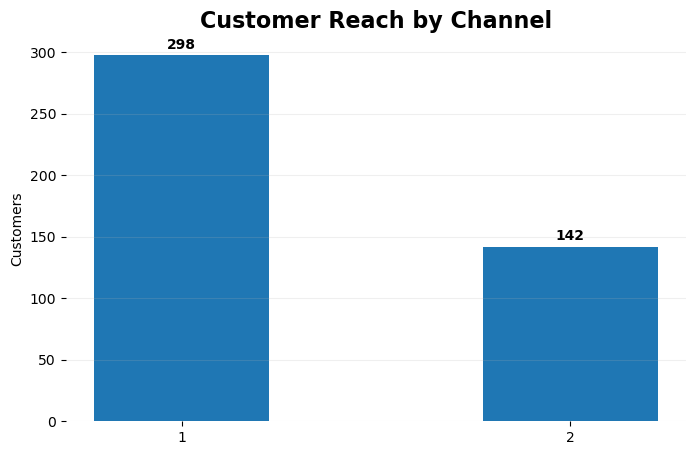

In [22]:
import matplotlib.pyplot as plt

x = df["Channel"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(x.index, x.values, width=.45)

for i, v in enumerate(x):
    plt.text(i + 1, v + 5, f"{v:,}", ha="center", fontweight="bold")

plt.title("Customer Reach by Channel", fontsize=16, fontweight="bold")
plt.xticks(x.index)
plt.ylabel("Customers")
plt.grid(axis="y", alpha=.2)
plt.box(False)
plt.show()

### Visualize customer distribution by Region

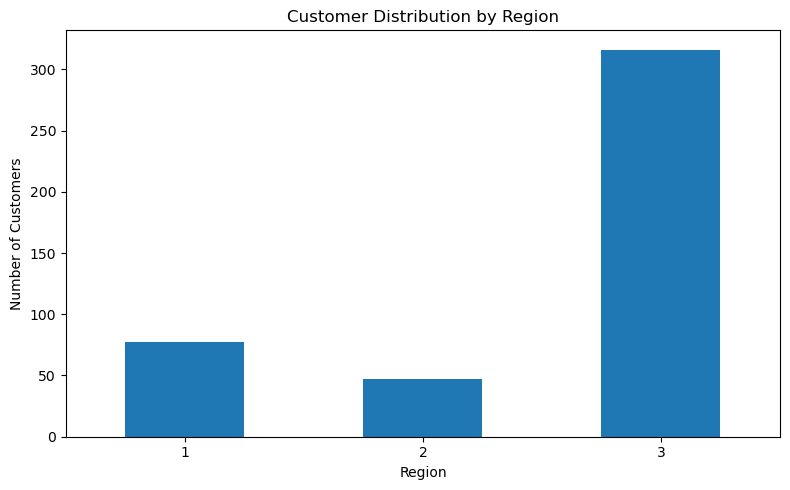

In [23]:
plt.figure(figsize=(8, 5))

df["Region"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analyze average spending

In [24]:
# Calculate average spending for each product category
average_spending = df[spending_columns].mean()

print("Average spending:")
print(average_spending.sort_values(ascending=False))

Average spending:
Fresh               12000.297727
Grocery              7951.277273
Milk                 5796.265909
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicatessen         1524.870455
dtype: float64


### Visualize average spending

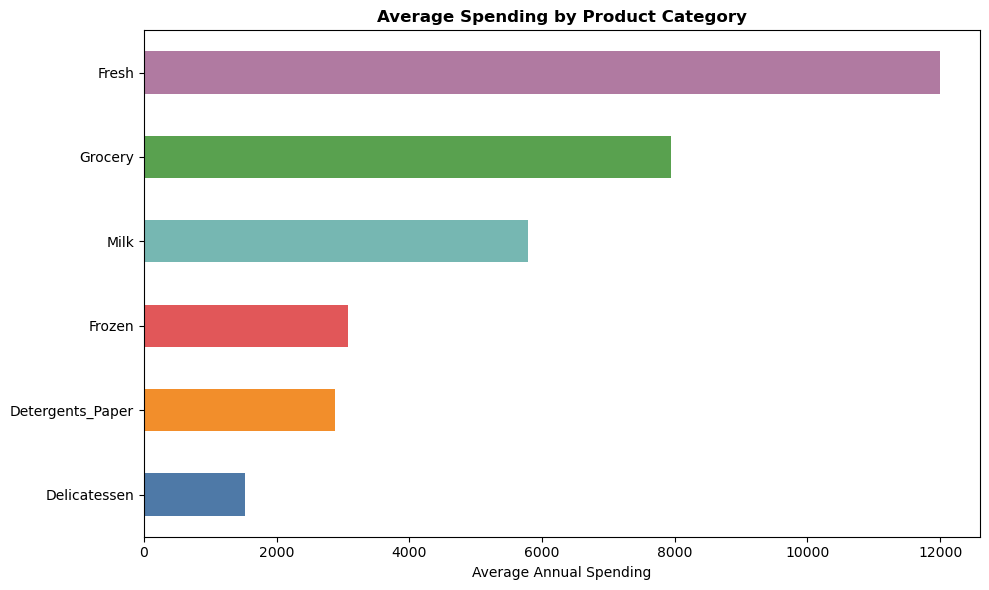

In [26]:
plt.figure(figsize=(10,6))

average_spending.sort_values().plot(
    kind="barh",
    color=["#4E79A7","#F28E2B","#E15759","#76B7B2","#59A14F","#B07AA1"]
)

plt.title("Average Spending by Product Category", fontweight="bold")
plt.xlabel("Average Annual Spending")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Compare spending by Channel

In [27]:
channel_spending = df.groupby("Channel")[spending_columns].mean()

print(channel_spending)

                Fresh          Milk       Grocery       Frozen  \
Channel                                                          
1        13475.560403   3451.724832   3962.137584  3748.251678   
2         8904.323944  10716.500000  16322.852113  1652.612676   

         Detergents_Paper  Delicatessen  
Channel                                  
1              790.560403   1415.956376  
2             7269.507042   1753.436620  


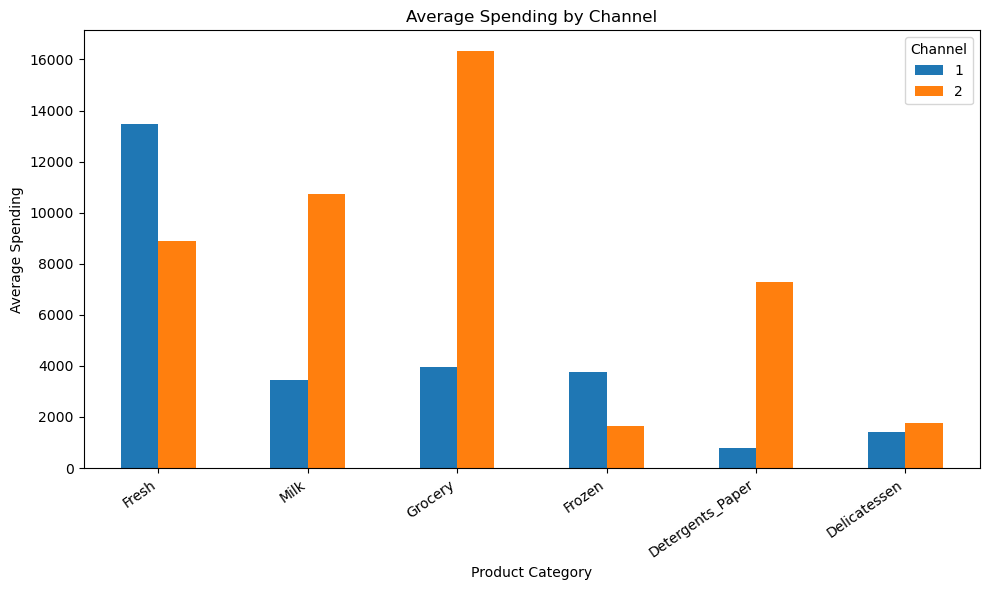

In [28]:
channel_spending.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Spending by Channel")
plt.xlabel("Product Category")
plt.ylabel("Average Spending")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Channel")
plt.tight_layout()
plt.show()

### Compare spending by Region

In [29]:
region_spending = df.groupby("Region")[spending_columns].mean()

print(region_spending)

               Fresh         Milk      Grocery       Frozen  Detergents_Paper  \
Region                                                                          
1       11101.727273  5486.415584  7403.077922  3000.337662       2651.116883   
2        9887.680851  5088.170213  9218.595745  4045.361702       3687.468085   
3       12533.471519  5977.085443  7896.363924  2944.594937       2817.753165   

        Delicatessen  
Region                
1        1354.896104  
2        1159.702128  
3        1620.601266  


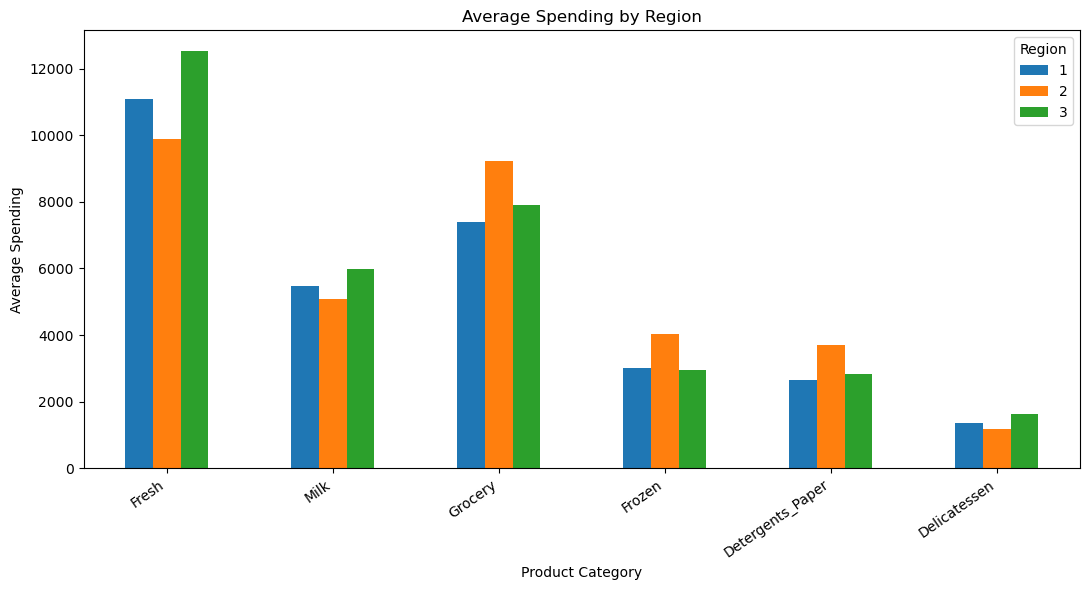

In [30]:
region_spending.T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Average Spending by Region")
plt.xlabel("Product Category")
plt.ylabel("Average Spending")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

### Correlation analysis

In [31]:
correlation_matrix = df[spending_columns].corr()

print(correlation_matrix)

                     Fresh      Milk   Grocery    Frozen  Detergents_Paper  \
Fresh             1.000000  0.100510 -0.011854  0.345881         -0.101953   
Milk              0.100510  1.000000  0.728335  0.123994          0.661816   
Grocery          -0.011854  0.728335  1.000000 -0.040193          0.924641   
Frozen            0.345881  0.123994 -0.040193  1.000000         -0.131525   
Detergents_Paper -0.101953  0.661816  0.924641 -0.131525          1.000000   
Delicatessen      0.244690  0.406368  0.205497  0.390947          0.069291   

                  Delicatessen  
Fresh                 0.244690  
Milk                  0.406368  
Grocery               0.205497  
Frozen                0.390947  
Detergents_Paper      0.069291  
Delicatessen          1.000000  


### Correlation heatmap

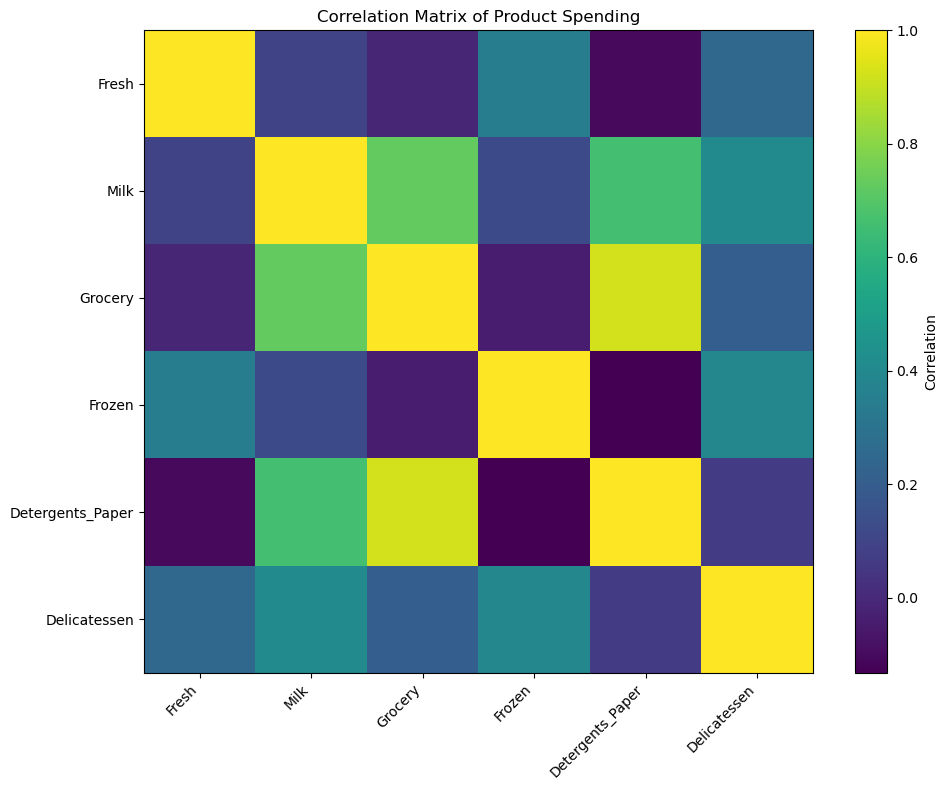

In [32]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(spending_columns)),
    spending_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(spending_columns)),
    spending_columns
)

plt.title("Correlation Matrix of Product Spending")

plt.tight_layout()
plt.show()

### Grocery vs Detergents/Paper relationship

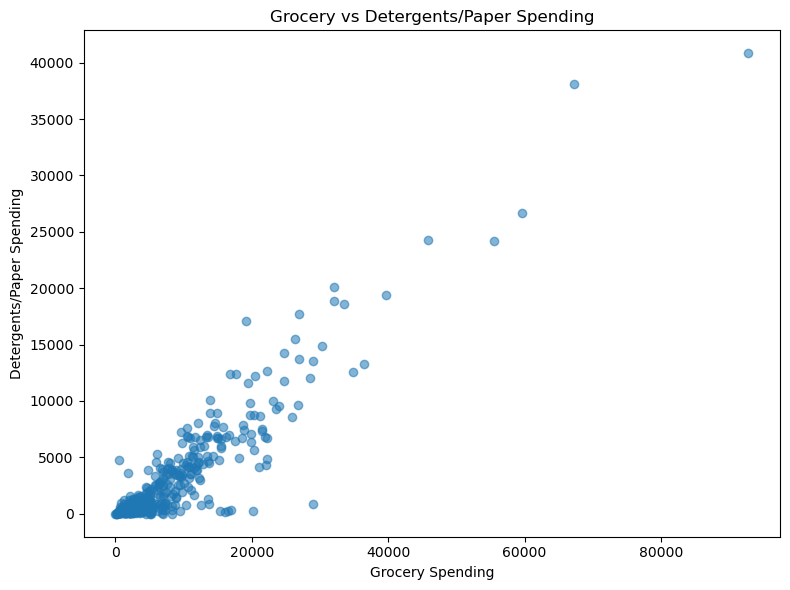

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Grocery"],
    df["Detergents_Paper"],
    alpha=0.55
)

plt.title("Grocery vs Detergents/Paper Spending")
plt.xlabel("Grocery Spending")
plt.ylabel("Detergents/Paper Spending")

plt.tight_layout()
plt.show()

### Distribution of each numerical variable

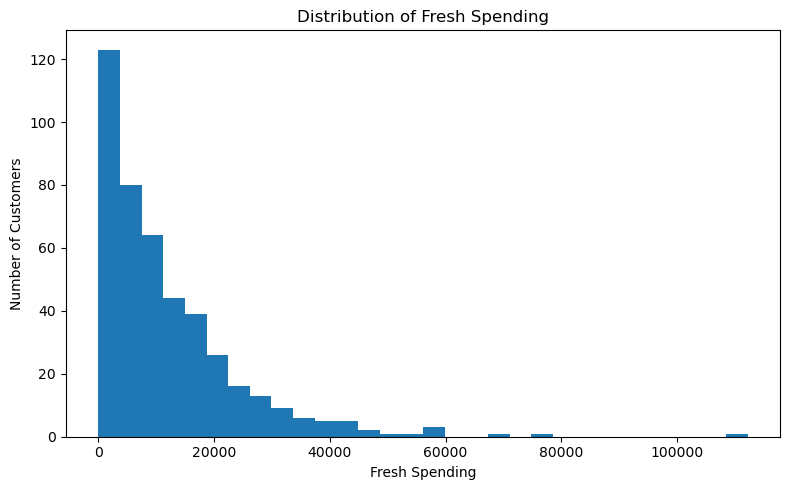

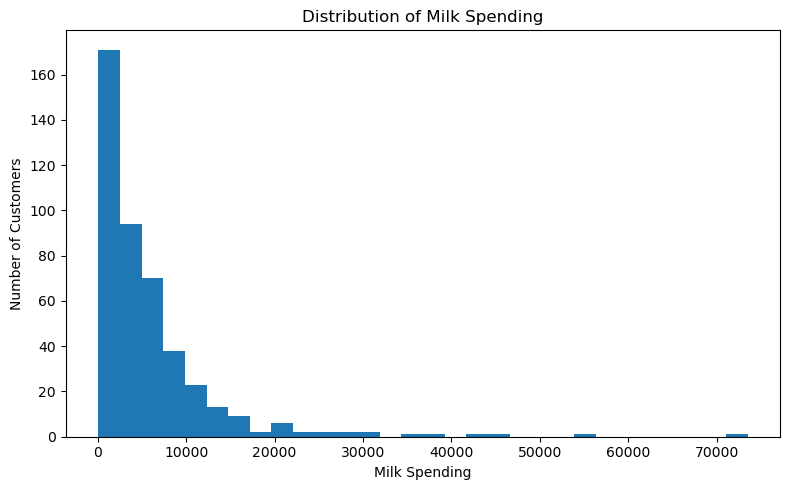

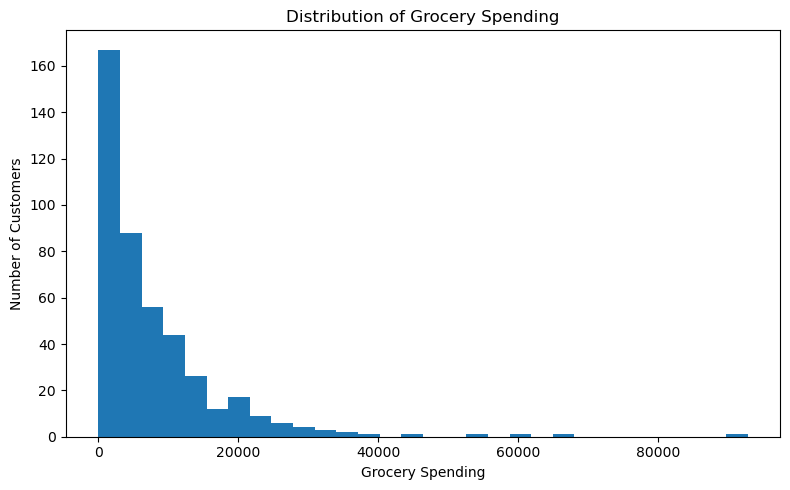

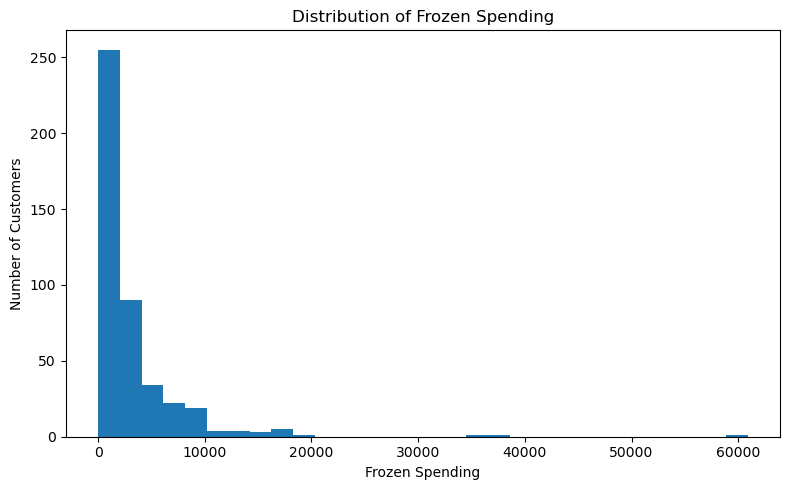

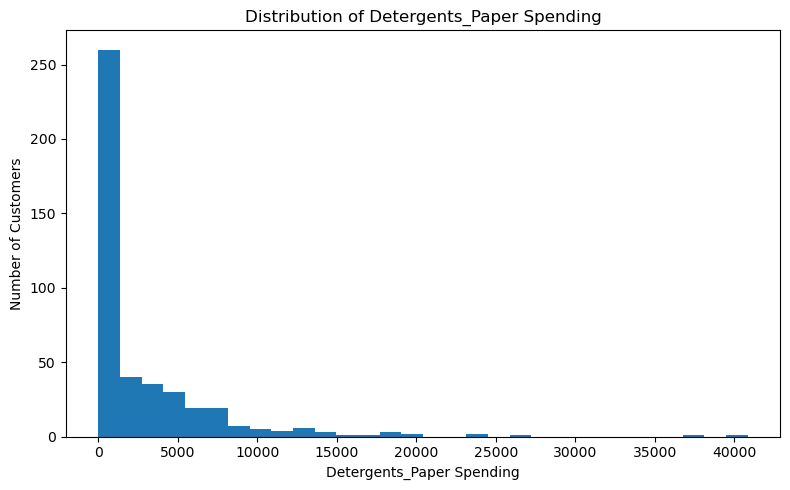

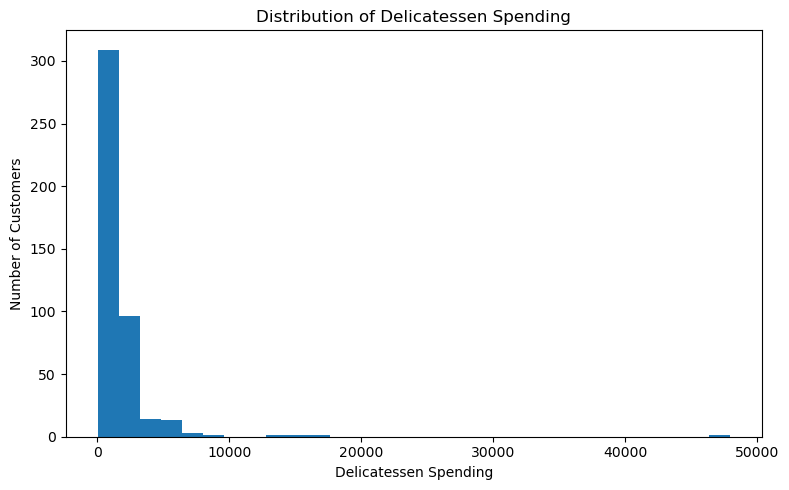

In [34]:
for column in spending_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column],
        bins=30
    )

    plt.title(f"Distribution of {column} Spending")
    plt.xlabel(f"{column} Spending")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

### Boxplots for detecting outliers

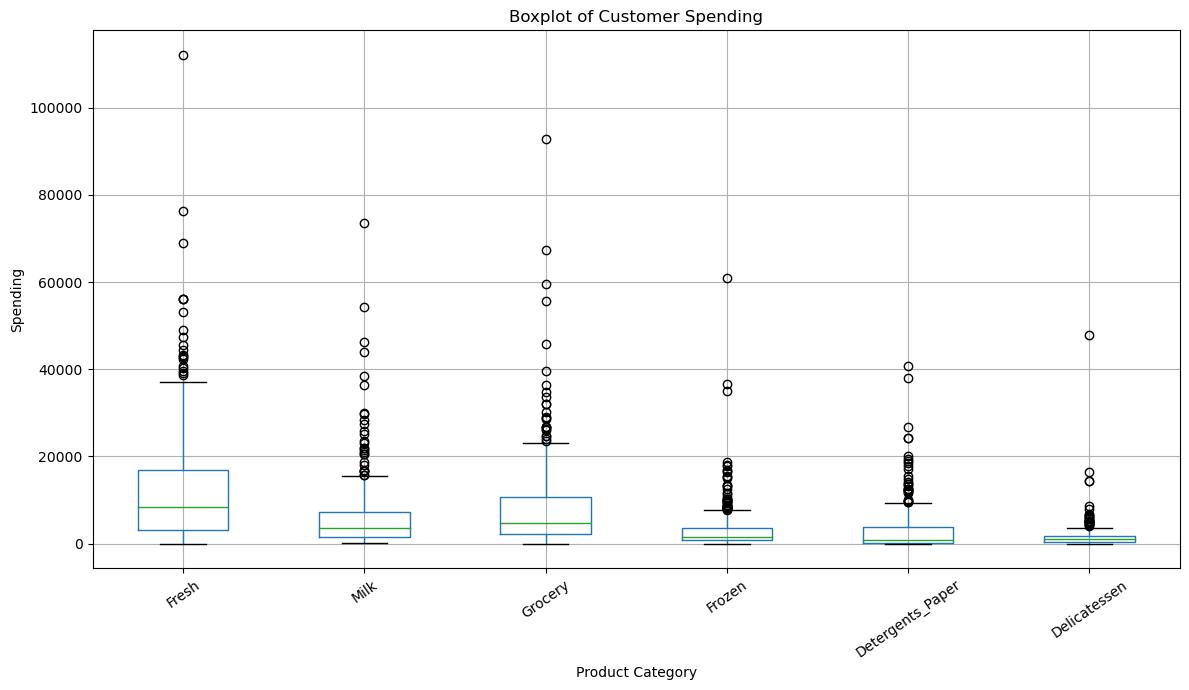

In [35]:
plt.figure(figsize=(12, 7))

df[spending_columns].boxplot()

plt.title("Boxplot of Customer Spending")
plt.xlabel("Product Category")
plt.ylabel("Spending")

plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### Calculate total customer spending

In [36]:
df["Total_Spending"] = df[spending_columns].sum(axis=1)

df[["Channel", "Region", "Total_Spending"]].head()

,Channel,Region,Total_Spending
0,2,3,34112
1,2,3,33266
2,2,3,36610
3,1,3,27381
4,2,3,46100


### Top 10 highest-spending customers

In [37]:
top_customers = df.sort_values(
    "Total_Spending",
    ascending=False
).head(10)

print(top_customers)

     Channel  Region   Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
85         2       3   16117  46197    92780    1026             40827   
47         2       3   44466  54259    55571    7782             24171   
181        1       3  112151  29627    18148   16745              4948   
183        1       3   36847  43950    20170   36534               239   
61         2       3   35942  38369    59598    3254             26701   
86         2       3   22925  73498    32114     987             20070   
325        1       2   32717  16784    13626   60869              1272   
333        2       2    8565   4980    67298     131             38102   
23         2       3   26373  36423    22019    5154              4337   
211        2       1   12119  28326    39694    4736             19410   

     Delicatessen  Total_Spending  
85           2944          199891  
47           6465          192714  
181          8550          190169  
183         47943          185683  
61   

### Visualize total spending

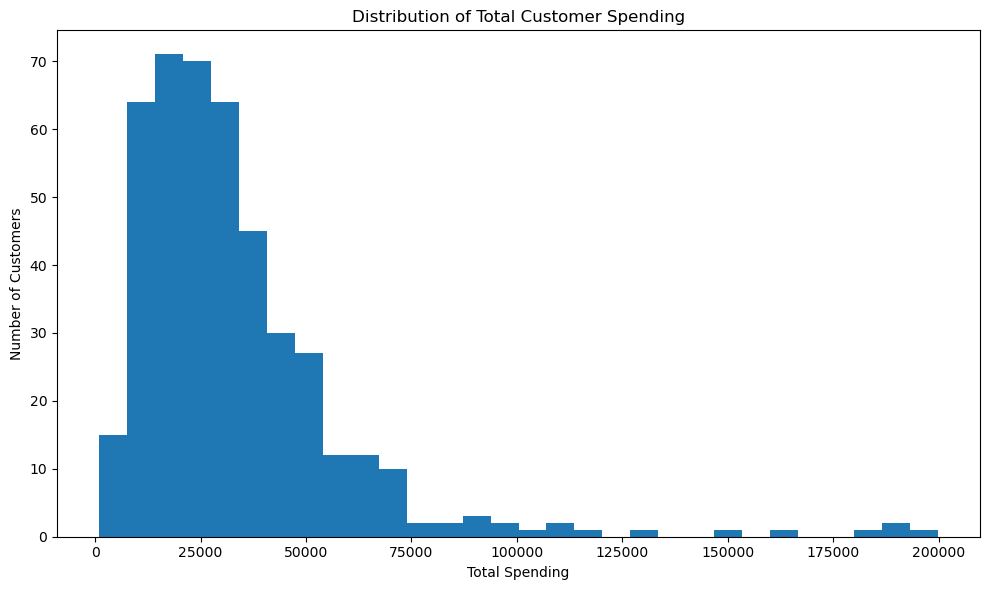

In [38]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Total_Spending"],
    bins=30
)

plt.title("Distribution of Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Summary and Conclusion

Overall, the analysis provided a clear understanding of customer spending patterns across different products, regions, and sales channels. The data was complete and did not contain missing values, which made it suitable for further analysis.

The findings showed that Fresh products had the highest average spending, while Delicatessen had the lowest. Customer spending varied considerably, with some customers spending much more than others. Customers using Channel 2 generally spent more on Milk, Grocery, and Detergents/Paper, even though Channel 1 had more customers.

One of the most noticeable findings was the strong relationship between Grocery and Detergents/Paper spending. This suggests that customers who spend more on groceries often tend to spend more on household-related products as well.

In general, the analysis provides useful information that can help a business understand its customers, improve marketing strategies, identify valuable customers, and explore opportunities for product bundling and cross-selling. It also provides a good foundation for more detailed customer analysis in the future.
